# Data Cleaning - Ames Housing

Pratikum Data Mining Coursera minggu 1

Di notebook ini saya mencobaa latihan membersihkan data sebelum dipakai buat modeling. Topiknya: transformasi log, duplikat, missing value, scaling, dan outlier. Datasetnya data penjualan rumah di Ames, Iowa (2006-2010), target yang mau diprediksi adalah `SalePrice`.

## Dataset

File yang dipakai: `Ames_Housing_Data1.tsv`.:

https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML0232EN-SkillsNetwork/asset/Ames_Housing_Data1.tsv

Dataset aslinya dari De Cock (2011), "Ames, Iowa: Alternative to the Boston Housing Data as an End of Semester Regression Project".

## 1. Import library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import MinMaxScaler, StandardScaler

sns.set_style("whitegrid")

## 2. Data Reading

In [2]:
PATH = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML0232EN-SkillsNetwork/asset/Ames_Housing_Data1.tsv"
raw = pd.read_csv(PATH, sep="\t")
print(raw.shape)
raw.head()

(2931, 82)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
2,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
3,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
4,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000


In [3]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2931 entries, 0 to 2930
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2931 non-null   int64  
 1   PID              2931 non-null   int64  
 2   MS SubClass      2931 non-null   int64  
 3   MS Zoning        2931 non-null   object 
 4   Lot Frontage     2441 non-null   float64
 5   Lot Area         2931 non-null   int64  
 6   Street           2931 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2931 non-null   object 
 9   Land Contour     2931 non-null   object 
 10  Utilities        2931 non-null   object 
 11  Lot Config       2931 non-null   object 
 12  Land Slope       2931 non-null   object 
 13  Neighborhood     2931 non-null   object 
 14  Condition 1      2931 non-null   object 
 15  Condition 2      2931 non-null   object 
 16  Bldg Type        2931 non-null   object 
 17  House Style   

In [4]:
# df ini yang nanti terus dibersihkan, raw dibiarkan utuh buat pembanding
df = raw.copy()
df["SalePrice"].describe()

,SalePrice
count,2931.000000
mean,180807.729785
std,79875.557267
min,12789.000000
25%,129500.000000
50%,160000.000000
75%,213500.000000
max,755000.000000


Dari `describe()` bisa dilihat selisih antara nilai tengah (median) dan rata-rata cukup jauh, dan nilai maksimumnya jauh di atas persentil 75. Jadi kemungkinan distribusi harga rumah tidak simetris. Ini dicek lagi di bagian transformasi log.

### Latihan 1: kategori pada `Sale Condition`

In [5]:
kondisi = df["Sale Condition"].value_counts()
persen = df["Sale Condition"].value_counts(normalize=True).mul(100).round(2)
pd.concat([kondisi, persen], axis=1, keys=["jumlah", "persen"])

,jumlah,persen
Sale Condition,,
Normal,2414,82.36
Partial,245,8.36
Abnorml,190,6.48
Family,46,1.57
Alloca,24,0.82
AdjLand,12,0.41


Kategori `Normal` mendominasi, sisanya jauh lebih sedikit. Kategori yang jarang muncul perlu diperhatikan kalau nanti dipakai sebagai fitur.

## 3. Korelasi dengan SalePrice

Sebelum bersih-bersih, cek dulu fitur numerik mana yang paling berhubungan dengan harga. Pakai korelasi Pearson, ambil yang nilai mutlaknya di atas 0.5.

In [6]:
num_cols = df.select_dtypes(include="number")
korelasi = num_cols.corr()["SalePrice"].drop("SalePrice")
kuat = korelasi[korelasi.abs() > 0.5].sort_values(ascending=False)

print(f"{len(kuat)} fitur dengan korelasi kuat terhadap SalePrice")
kuat

11 fitur dengan korelasi kuat terhadap SalePrice


,SalePrice
Overall Qual,0.799226
Gr Liv Area,0.706791
Garage Cars,0.647891
Garage Area,0.640411
Total Bsmt SF,0.632270
1st Flr SF,0.621672
Year Built,0.558340
Full Bath,0.545339
Year Remod/Add,0.532664
Garage Yr Blt,0.526808


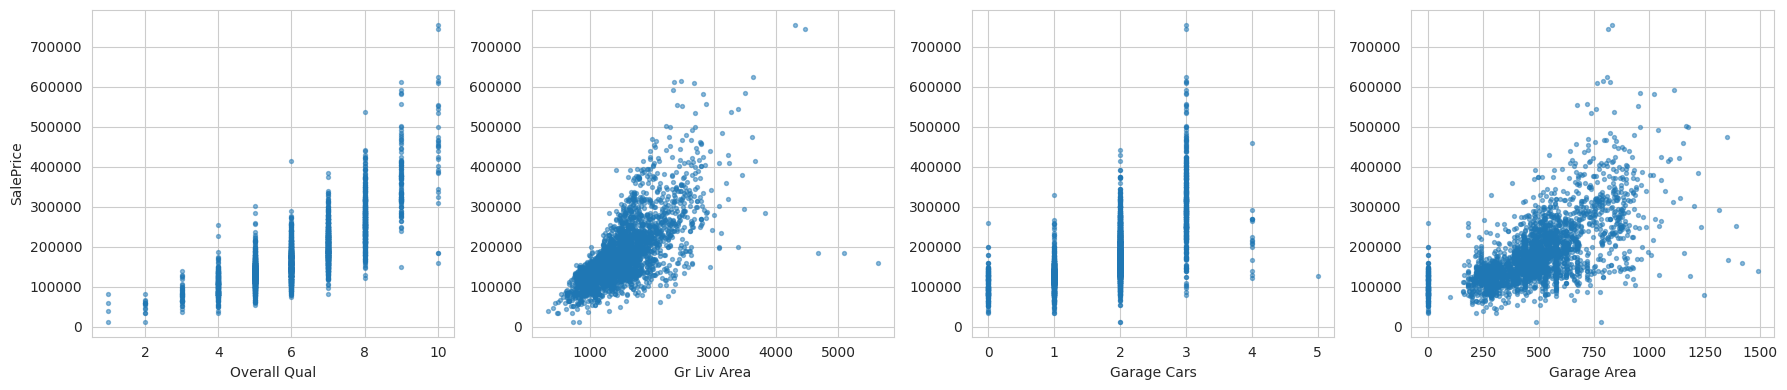

In [7]:
# scatter plot untuk 4 fitur dengan korelasi tertinggi
fitur_top = kuat.index[:4]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, f in zip(axes, fitur_top):
    ax.scatter(df[f], df["SalePrice"], s=8, alpha=0.5)
    ax.set_xlabel(f)
axes[0].set_ylabel("SalePrice")
plt.tight_layout()
plt.show()

Fitur seperti `Overall Qual` dan `Gr Liv Area` kelihatan punya pola naik yang jelas terhadap harga. Dari scatter ini juga sudah mulai kelihatan beberapa titik yang aneh, dibahas di bagian outlier.

## 4. Transformasi log

Cek bentuk distribusi `SalePrice` dulu, lalu hitung skewness-nya.

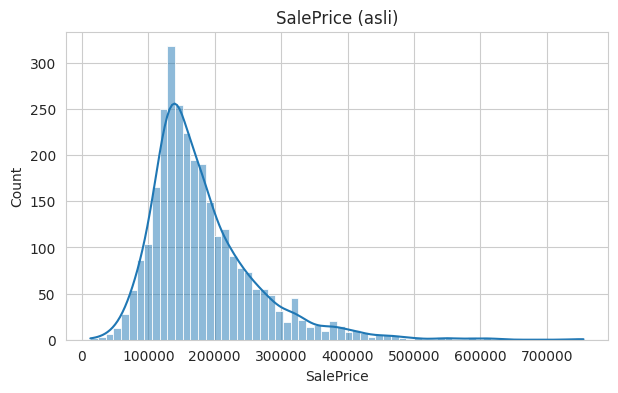

skewness: 1.743


In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(df["SalePrice"], kde=True, ax=ax)
ax.set_title("SalePrice (asli)")
plt.show()

print("skewness:", round(df["SalePrice"].skew(), 3))

Acuan skewness: antara -0.5 sampai 0.5 dianggap cukup simetris, di luar -1 sampai 1 dianggap sangat miring. Kalau hasilnya positif besar, ekor distribusi memanjang ke kanan (banyak rumah murah, sedikit yang sangat mahal).

Coba ditransformasi pakai log.

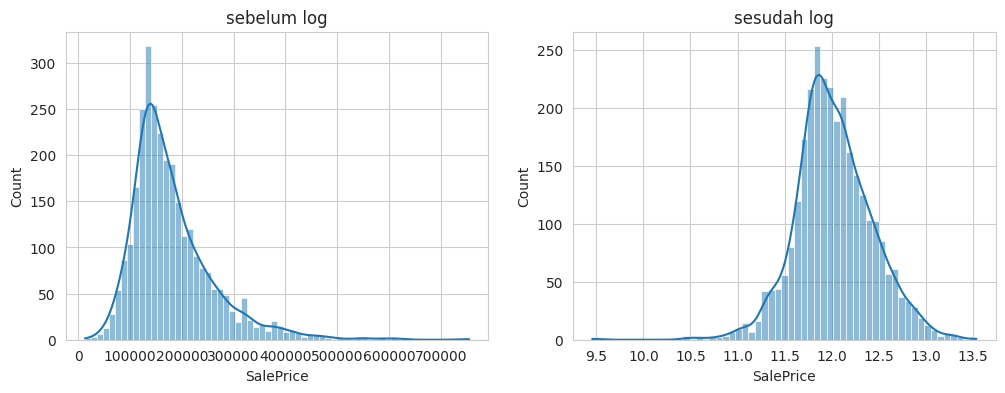

skewness sebelum: 1.743
skewness sesudah: -0.015


In [9]:
harga_log = np.log(df["SalePrice"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["SalePrice"], kde=True, ax=axes[0])
axes[0].set_title("sebelum log")
sns.histplot(harga_log, kde=True, ax=axes[1])
axes[1].set_title("sesudah log")
plt.show()

print("skewness sebelum:", round(df["SalePrice"].skew(), 3))
print("skewness sesudah:", round(harga_log.skew(), 3))

Sesudah di-log bentuknya jauh lebih mendekati lonceng dan skewness turun mendekati 0. Selain log ada juga akar kuadrat dan Box-Cox. Sekalian dibandingkan:

In [10]:
akar = np.sqrt(df["SalePrice"])
bc, lam = stats.boxcox(df["SalePrice"])

pd.Series({
    "asli": df["SalePrice"].skew(),
    "log": harga_log.skew(),
    "akar kuadrat": akar.skew(),
    f"box-cox (lambda={lam:.2f})": pd.Series(bc).skew(),
}).round(3)

,0
asli,1.743
log,-0.015
akar kuadrat,0.884
box-cox (lambda=0.01),0.002


### Latihan 2: `Lot Area`

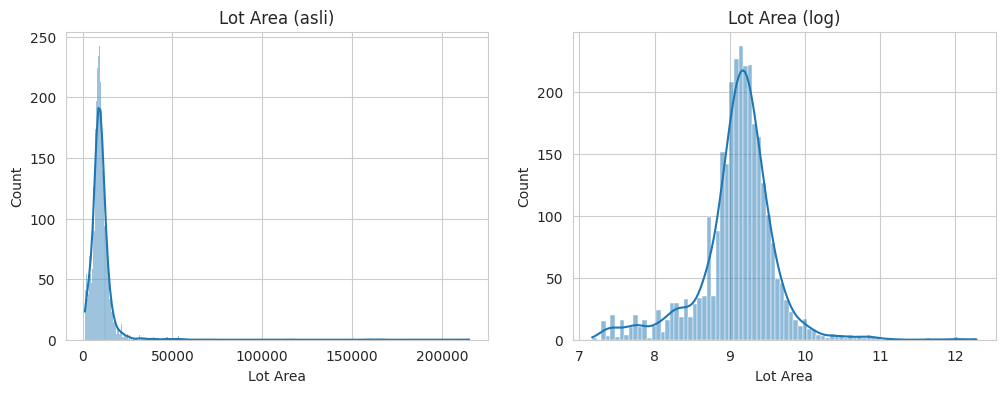

skewness asli: 12.778
skewness log : -0.495


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["Lot Area"], kde=True, ax=axes[0])
axes[0].set_title("Lot Area (asli)")
sns.histplot(np.log(df["Lot Area"]), kde=True, ax=axes[1])
axes[1].set_title("Lot Area (log)")
plt.show()

print("skewness asli:", round(df["Lot Area"].skew(), 3))
print("skewness log :", round(np.log(df["Lot Area"]).skew(), 3))

`Lot Area` miringnya lebih parah daripada `SalePrice`, jadi log cukup membantu. Kemungkinan besar sebagian karena ada beberapa lahan yang luasnya ekstrem (dilihat lagi di bagian outlier).

## 5. Duplikat

Kolom `PID` seharusnya unik untuk tiap rumah, jadi dipakai buat deteksi duplikat.

In [12]:
print("jumlah PID dobel:", df["PID"].duplicated().sum())

# keep=False supaya kedua baris yang kembar tampil
df[df["PID"].duplicated(keep=False)]

jumlah PID dobel: 1


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000


In [13]:
sebelum = len(df)
df = df.drop_duplicates(subset="PID", keep="first")
print(f"{sebelum} -> {len(df)} baris")

2931 -> 2930 baris


### Latihan 3: hapus duplikat berdasarkan kolom `Order`

In [14]:
tes = df.drop_duplicates(subset=["Order"])
print("sebelum:", len(df), "| sesudah:", len(tes))

sebelum: 2930 | sesudah: 2930


Jumlah barisnya tidak berubah karena `Order` memang nomor urut yang unik. Jadi memilih kolom untuk cek duplikat itu penting: kolom yang salah bisa menghapus data yang sebenarnya valid.

## 6. Missing value

In [15]:
hilang = df.isnull().sum()
hilang = hilang[hilang > 0].sort_values(ascending=False)
tabel = pd.DataFrame({"jumlah": hilang, "persen": (hilang / len(df) * 100).round(1)})
tabel.head(15)

,jumlah,persen
Pool QC,2917,99.6
Misc Feature,2824,96.4
Alley,2732,93.2
Fence,2358,80.5
Mas Vnr Type,1775,60.6
Fireplace Qu,1422,48.5
Lot Frontage,490,16.7
Garage Qual,159,5.4
Garage Cond,159,5.4
Garage Yr Blt,159,5.4


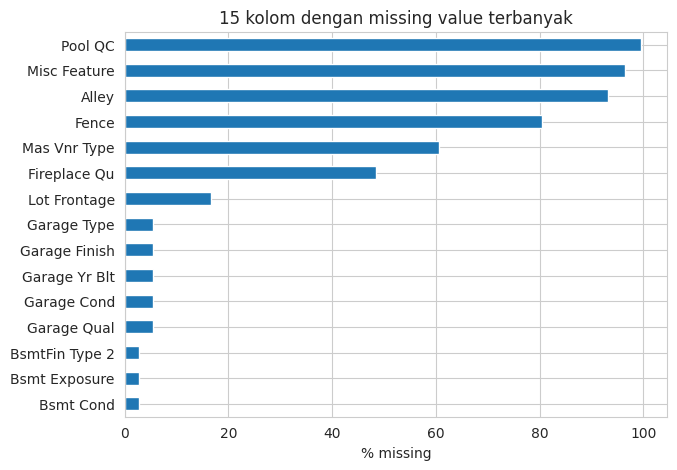

In [16]:
tabel.head(15)["persen"].sort_values().plot(kind="barh", figsize=(7, 5))
plt.xlabel("% missing")
plt.title("15 kolom dengan missing value terbanyak")
plt.show()

Ada tiga cara menangani missing value. coba ketiganya di `Lot Frontage` pada salinan data supaya `df` tidak ikut berubah.

In [17]:
opsi_hapus_baris = df.dropna(subset=["Lot Frontage"])
opsi_hapus_kolom = df.drop(columns="Lot Frontage")

median_lf = df["Lot Frontage"].median()
opsi_isi = df.copy()
opsi_isi["Lot Frontage"] = opsi_isi["Lot Frontage"].fillna(median_lf)

print("asli        :", df.shape)
print("hapus baris :", opsi_hapus_baris.shape)
print("hapus kolom :", opsi_hapus_kolom.shape)
print("isi median  :", opsi_isi.shape, "| median =", median_lf)

asli        : (2930, 82)
hapus baris : (2440, 82)
hapus kolom : (2930, 81)
isi median  : (2930, 82) | median = 68.0


Hapus baris membuang cukup banyak data, hapus kolom membuang satu fitur sekaligus. Untuk `Lot Frontage` pilih isi dengan median karena kolomnya masih berguna dan median tidak terpengaruh outlier.

In [18]:
df["Lot Frontage"] = df["Lot Frontage"].fillna(median_lf)
df["Lot Frontage"].isnull().sum()

np.int64(0)

### Latihan 4: `Mas Vnr Area` diisi dengan rata-rata

In [19]:
print("missing sebelum:", df["Mas Vnr Area"].isnull().sum())
df["Mas Vnr Area"] = df["Mas Vnr Area"].fillna(df["Mas Vnr Area"].mean())
print("missing sesudah:", df["Mas Vnr Area"].isnull().sum())

missing sebelum: 23
missing sesudah: 0


## 7. Scaling

Ada 2 cara yang umum:
- min-max (normalisasi): nilai dipetakan ke rentang 0 sampai 1
- standardisasi: nilai dikurangi rata-rata lalu dibagi standar deviasi, hasilnya rata-rata 0 dan std 1

In [20]:
kolom = ["Lot Area", "Gr Liv Area", "Garage Area", "SalePrice"]
x = df[kolom]

x_minmax = pd.DataFrame(MinMaxScaler().fit_transform(x), columns=kolom, index=x.index)
x_std = pd.DataFrame(StandardScaler().fit_transform(x), columns=kolom, index=x.index)

print("min-max:")
print(x_minmax.describe().loc[["min", "max"]].round(3))
print()
print("standardisasi:")
print(x_std.describe().loc[["mean", "std"]].round(3))

min-max:
     Lot Area  Gr Liv Area  Garage Area  SalePrice
min       0.0          0.0          0.0        0.0
max       1.0          1.0          1.0        1.0

standardisasi:
      Lot Area  Gr Liv Area  Garage Area  SalePrice
mean       0.0          0.0          0.0       -0.0
std        1.0          1.0          1.0        1.0


### Latihan 5: standardisasi `SalePrice` saja

In [21]:
harga_std = StandardScaler().fit_transform(df[["SalePrice"]])
print(harga_std[:5].ravel().round(3))
print("mean:", harga_std.mean().round(3), "| std:", harga_std.std().round(3))

[ 0.428 -0.949 -0.11   0.791  0.114]
mean: -0.0 | std: 1.0


## 8. Outlier

### Univariat (box plot)

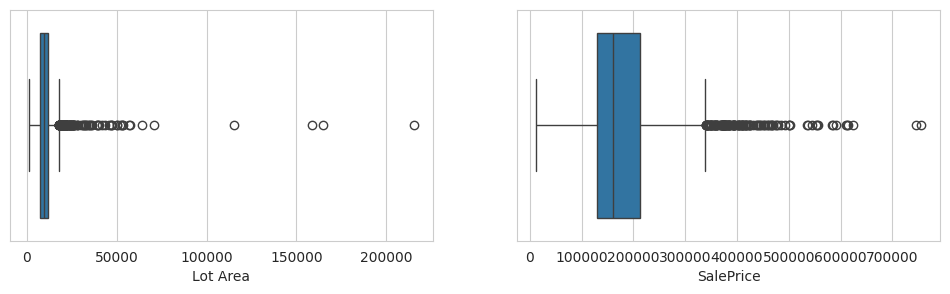

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
sns.boxplot(x=df["Lot Area"], ax=axes[0])
sns.boxplot(x=df["SalePrice"], ax=axes[1])
plt.show()

In [23]:
def batas_iqr(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

for nama in ["Lot Area", "SalePrice"]:
    bawah, atas = batas_iqr(df[nama])
    jml = ((df[nama] < bawah) | (df[nama] > atas)).sum()
    print(f"{nama}: batas {bawah:.0f} s/d {atas:.0f}, {jml} titik di luar batas")

Lot Area: batas 1268 s/d 17728, 127 titik di luar batas
SalePrice: batas 3500 s/d 339500, 137 titik di luar batas


Banyak titik di luar batas IQR, tapi rumah mahal atau lahan luas itu masih wajar terjadi di dunia nyata, jadi tidak otomatis dibuang. Yang dicurigai itu titik yang tidak mengikuti pola.

### Bivariat (`Gr Liv Area` vs `SalePrice`)

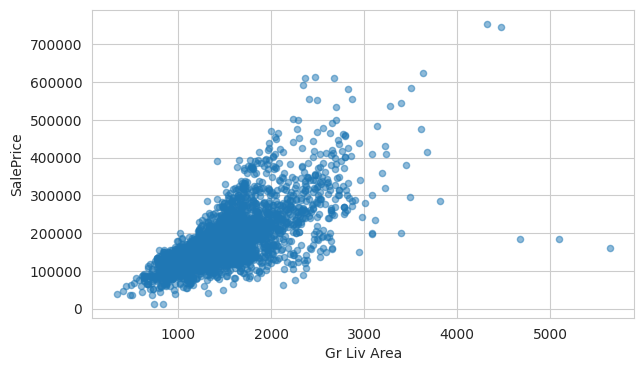

In [24]:
df.plot.scatter(x="Gr Liv Area", y="SalePrice", figsize=(7, 4), alpha=0.5)
plt.show()

Ada beberapa rumah dengan luas bangunan sangat besar. Dua titik di atas 5000 sqft harganya rendah dan tidak sejalan dengan tren, itu yang dibuang. Titik-titik besar lainnya harganya tinggi dan masih mengikuti tren, jadi dipertahankan.

In [25]:
# cari berdasarkan kondisi, bukan nomor index, supaya tidak salah hapus kalau urutan data berubah
mencurigakan = df[(df["Gr Liv Area"] > 5000) & (df["SalePrice"] < 300000)]
mencurigakan[["Order", "Gr Liv Area", "SalePrice"]]

,Order,Gr Liv Area,SalePrice
1499,1499,5642,160000
2181,2181,5095,183850


2930 -> 2928


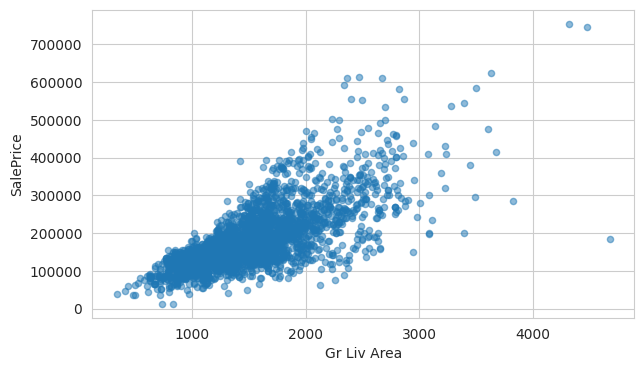

In [26]:
df_bersih = df.drop(mencurigakan.index)
print(len(df), "->", len(df_bersih))

df_bersih.plot.scatter(x="Gr Liv Area", y="SalePrice", figsize=(7, 4), alpha=0.5)
plt.show()

### Latihan 6: outlier pada `Lot Area`

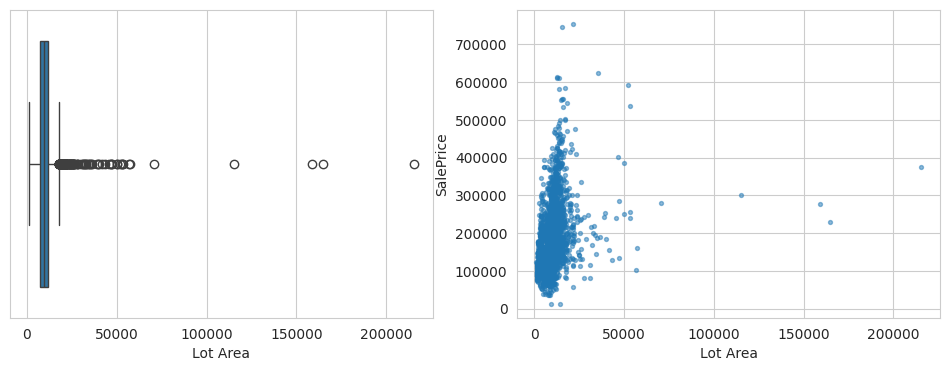

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df_bersih["Lot Area"], ax=axes[0])
axes[1].scatter(df_bersih["Lot Area"], df_bersih["SalePrice"], s=8, alpha=0.5)
axes[1].set_xlabel("Lot Area")
axes[1].set_ylabel("SalePrice")
plt.show()

In [28]:
df_bersih["z_lot"] = stats.zscore(df_bersih["Lot Area"])
print("jumlah |z| > 3:", (df_bersih["z_lot"].abs() > 3).sum())
df_bersih.nlargest(5, "Lot Area")[["Lot Area", "SalePrice", "z_lot"]].round(2)

jumlah |z| > 3: 27


,Lot Area,SalePrice,z_lot
957,215245,375000,26.30
1571,164660,228950,19.81
2116,159000,277000,19.09
2072,115149,302000,13.47
2767,70761,280000,7.77


Satu titik `Lot Area` terbesar jaraknya jauh sekali dari kumpulan data lainnya (z-score jauh di atas 3), jadi dibuang. Titik lain yang z-score-nya sedikit di atas 3 dibiarkan karena tidak sejauh itu dari kelompoknya.

In [29]:
df_bersih = df_bersih.drop(df_bersih["Lot Area"].idxmax())
df_bersih = df_bersih.drop(columns="z_lot")
print(df_bersih.shape)

(2927, 82)


### Z-score pada `Low Qual Fin SF`

In [30]:
z = pd.Series(stats.zscore(df_bersih["Low Qual Fin SF"]), index=df_bersih.index)
print("z-score tertinggi:", round(z.max(), 2))
print("jumlah |z| > 3   :", (z.abs() > 3).sum())
print("jumlah nilai 0   :", (df_bersih["Low Qual Fin SF"] == 0).sum(), "dari", len(df_bersih))

z-score tertinggi: 22.87
jumlah |z| > 3   : 31
jumlah nilai 0   : 2887 dari 2927


Kolom ini hampir semuanya bernilai 0, jadi nilai yang tidak nol langsung kelihatan sebagai z-score tinggi. Ini bukan outlier karena kesalahan data, tapi karena distribusinya memang sangat timpang. Menghapusnya otomatis kurang tepat.

## 9. Ringkasan

In [31]:
print("data awal   :", raw.shape)
print("data akhir  :", df_bersih.shape)
print("sisa missing di kolom yang ditangani:",
      df_bersih[["Lot Frontage", "Mas Vnr Area"]].isnull().sum().sum())

data awal   : (2931, 82)
data akhir  : (2927, 82)
sisa missing di kolom yang ditangani: 0


Yang dilakukan: 1 baris duplikat dibuang, `Lot Frontage` diisi median, `Mas Vnr Area` diisi rata-rata, lalu beberapa outlier di `Gr Liv Area` dan `Lot Area` dibuang. `SalePrice` sebaiknya di-log kalau nanti dipakai di regresi linear karena distribusinya miring.

Yang masih belum ditangani: kolom kategorikal dengan missing value banyak (misalnya `Pool QC`, `Alley`), karena butuh penanganan khusus.